<a href="https://colab.research.google.com/github/me1-3/Emsc2010-W5Lec1-8216285/blob/main/EMSC2010_W5_L1_u8216285.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#EMSC2010-W5-L1

## Random numbers
Below is some simple code to *generate uniformly* distributed random numbers. Don't worry about how the code works, we're just going to use it to demonstrate a concept.



In [ ]:
class SimpleRNG:
    """
    A Linear Congruential Generator (LCG).
    Formula: next = (a * current + c) % m
    """
    def __init__(self, seed=42):
        self.state = seed
        self.a = 1664525      # Multiplier
        self.c = 1013904223   # Increment
        self.m = 2**32        # Modulus

    def next_int(self):
        """Generate the next raw integer."""
        self.state = (self.a * self.state + self.c) % self.m
        return self.state

    def next_float(self):
        """Generate a float in [0, 1)."""
        return self.next_int() / self.m

Generate 5 random numbers using a *seed* and print them to the screen

In [ ]:
rng1 = SimpleRNG(seed=99)
for _ in range(5):
    print(f"  rng1: {rng1.next_float():.6f}")

  rng1: 0.274436
  rng1: 0.258240
  rng1: 0.605653
  rng1: 0.332487
  rng1: 0.364237


### Using Numpy
Rather than writing our own code, we typically use a package like ```numpy``` to generate random numbers.

In [ ]:
import numpy as np

# Create a generator with a fixed seed
rng = np.random.default_rng(seed=99)

# Generate an array of 5 numbers in [0, 1)
print(rng.uniform(size=5))

# Generate numbers in a custom range, e.g. [10, 20)
print(rng.uniform(low=10, high=20, size=5))

[0.50603067 0.56509163 0.51191596 0.97218637 0.61490314]
[15.68283498 12.86786723 15.54511453 14.67523526 16.10058008]


In [ ]:
x = rng.uniform(size=10000)*10+10

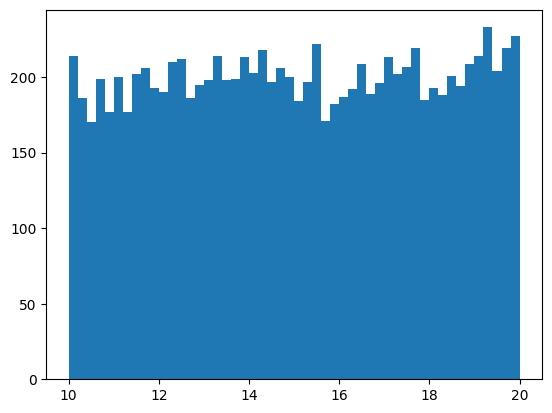

In [ ]:
import matplotlib.pyplot as plt
plt.hist(x, bins=50)
plt.show()

Kolmolgrov random numbers --> its only random if you have to repeat all the numbers (cant find a pattern, or a way to explain in the fewest words the sequence)

Monte carlo simulation/integration - for when you dont have the maths

In [34]:
Ntot = 1000
x = rng.uniform(size=Ntot)
y = rng.uniform(size=Ntot)
d = np.sqrt((x-0.5)**2 + (y-0.5)**2)
nc = np.sum(d<0.5)
print(nc)
ac = nc/Ntot
print(ac)
print(np.pi*0.5**2) #numbers not exact same bc not enough trials

790
0.79
0.7853981633974483


In [36]:
Ntot = 1000 #multiple dimensions
x = rng.uniform(size=Ntot)
y = rng.uniform(size=Ntot)
w = rng.uniform(size=Ntot)
z = rng.uniform(size=Ntot)
d = np.sqrt((x-0.5)**2 + (y-0.5)**2+(w-0.5)**2 + (z-0.5)**2)
nc = np.sum(d<0.5)
print(nc)
ac = nc/Ntot
print(ac)

320
0.32
